# House Sales Prediction EDA

House Sales Prediction EDA to check whether the data is cleaned or still uncleaned

### Importing Library

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

%matplotlib inline

## Load the Datasets

In [52]:
file_path = "datasets/kc_house_data.csv"
df = pd.read_csv(file_path)
print("Full train dataset shape is {}".format(df.shape))

Full train dataset shape is (21613, 21)


The data is composed of 21813 rows and 21 columns. We can see all dimension of our datasets by printing out our first 4 entries using the following codes

In [53]:
df.head(4)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000


4x21

- There are 19 feature columns. Using these features, your models has to predict the house sales indicated by the column name _price_

In [54]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

The table consist of numeric data, the date itself is not in the correct form which we will fix it during cleaning

## Data Cleaning

Beginning by copying datasets to our dummy datasets to protect our original data

In [55]:
data = df.copy()
data.head(4)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000


Begin by converting our date

In [56]:
data['date'] = pd.to_datetime(data['date'], format='%Y%m%dT%H%M%S')
data.head(4)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000


Our date has been reformatted into the correct one, now let's handle our missing data

In [57]:
data.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

No missing value detected, check for duplicate

In [58]:
data.duplicated().sum()
data[data.duplicated()]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15


No duplication found, value checking whether there are any invalid data or outlier exist

In [59]:
data.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,2014-10-29 04:38:01.959931648,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
min,1.000102e+06,2014-05-02 00:00:00,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,2014-07-22 00:00:00,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,2014-10-16 00:00:00,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,2015-02-17 00:00:00,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,2015-05-27 00:00:00,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631


## Distribution Check

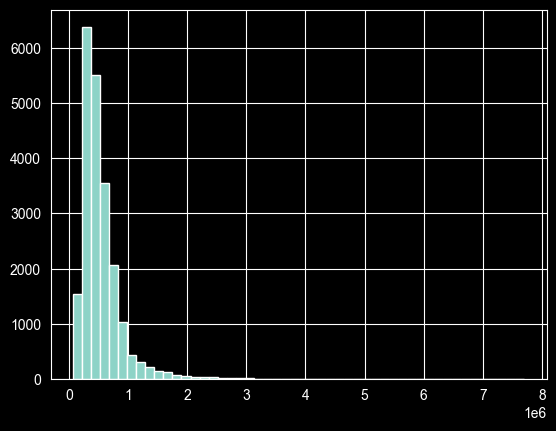

In [60]:
data['price'].hist(bins=50)
plt.show()

The distribution shown a right skeewer, which mean most of the house are priced lower than the least house that have higher price than the average. Since the number of the data itself is too high to read, we will add log price to transform the data to change the shape of the distribution (or even to compress the size of the number), making it more 'normal-like' data

In [61]:
data['log_price'] = np.log(data['price'])
data.head(4)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,log_price
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,12.309982
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,13.195614
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,12.100712
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,13.311329


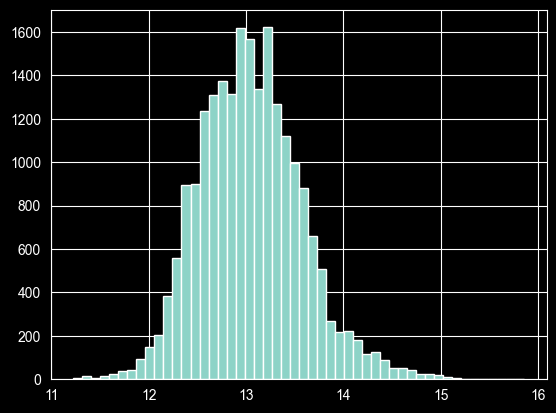

In [62]:
data['log_price'].hist(bins=50)
plt.show()

Now the data feels more stabled

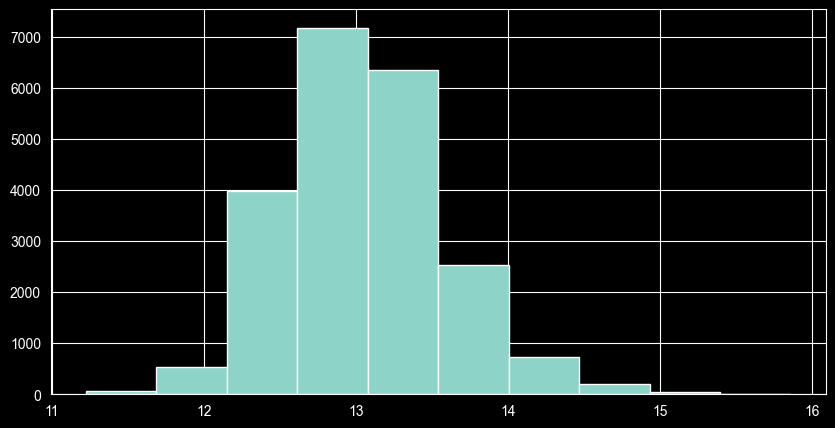

In [63]:
y = data['log_price']
y.hist(figsize=(10,5))
plt.show()

Now our data feels more 'normal-like' after transforming the price to 'log price' using ln of the price. We would want to check the other skew data, if we ever encounter it we should also transform it

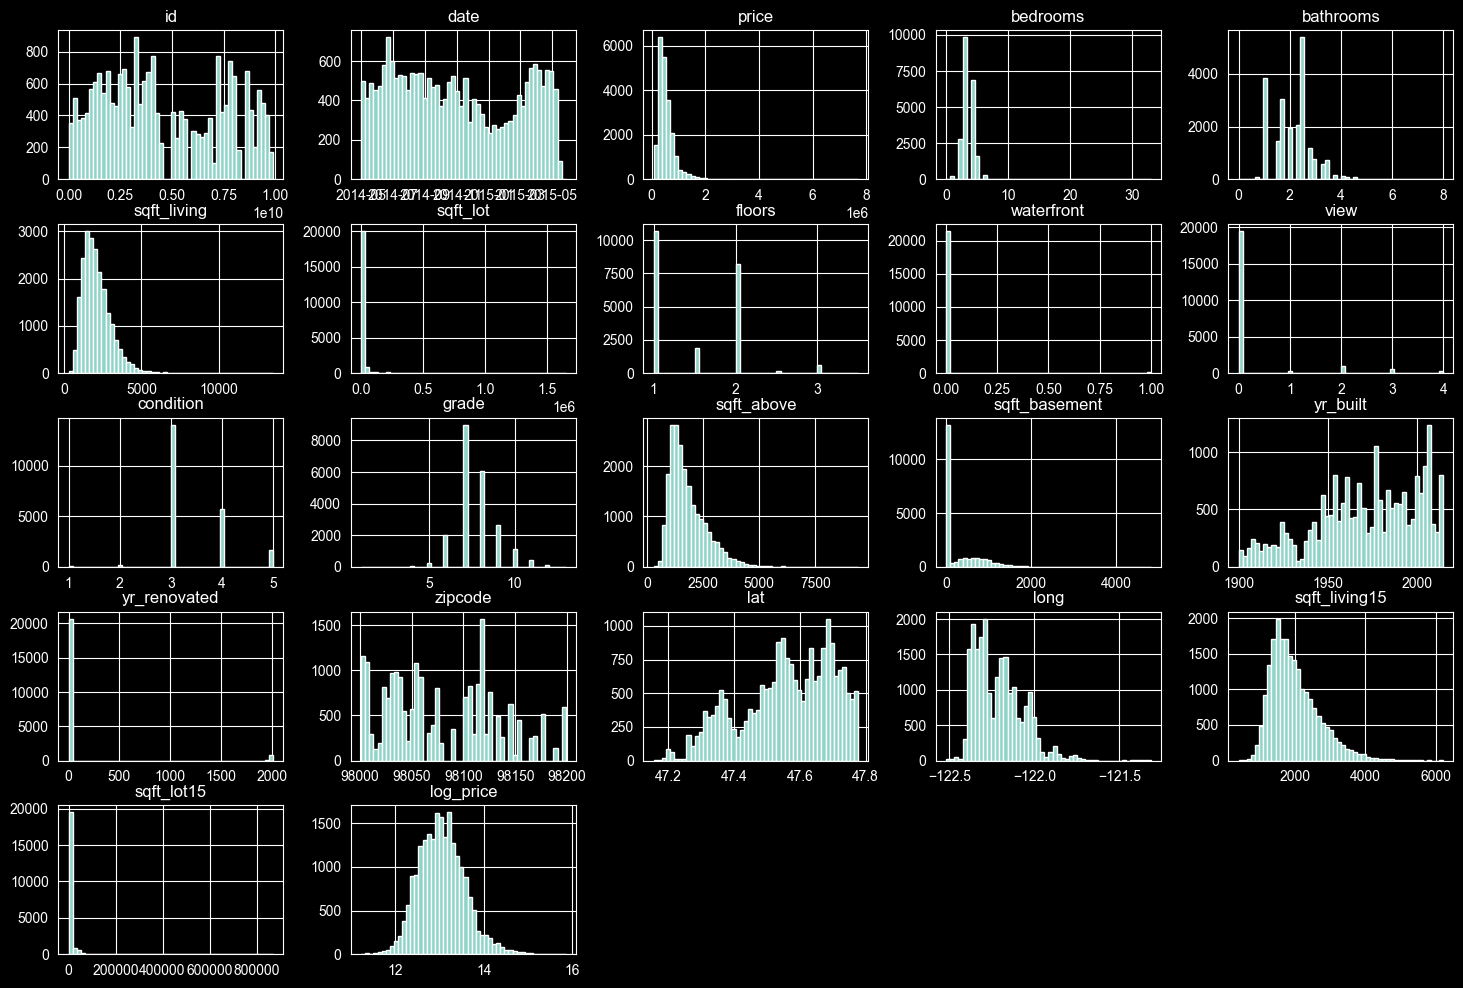

In [64]:
data.hist(figsize=(18,12), bins=50)
plt.show()

We see a lot of skew left and skew right that have to be transformed, but not everything, only the part with 'sqft_'

In [65]:
col_to_log = [
    'sqft_living15', 'sqft_living', 'sqft_above', 'sqft_lot', 'sqft_basement', 'sqft_lot15'
]

for col in col_to_log:
    if col in data.columns:
        data[f'log_{col}'] = np.log1p(data[col])

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'date'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'sqft_living'}>,
        <Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'floors'}>,
        <Axes: title={'center': 'waterfront'}>,
        <Axes: title={'center': 'view'}>],
       [<Axes: title={'center': 'condition'}>,
        <Axes: title={'center': 'grade'}>,
        <Axes: title={'center': 'sqft_above'}>,
        <Axes: title={'center': 'sqft_basement'}>,
        <Axes: title={'center': 'yr_built'}>],
       [<Axes: title={'center': 'yr_renovated'}>,
        <Axes: title={'center': 'zipcode'}>,
        <Axes: title={'center': 'lat'}>,
        <Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'sqft_living15'}>],
       [<Axes: title={'center': 'sqft_lot15'}>,
        <Axes: title={'center': 'log_price'}>

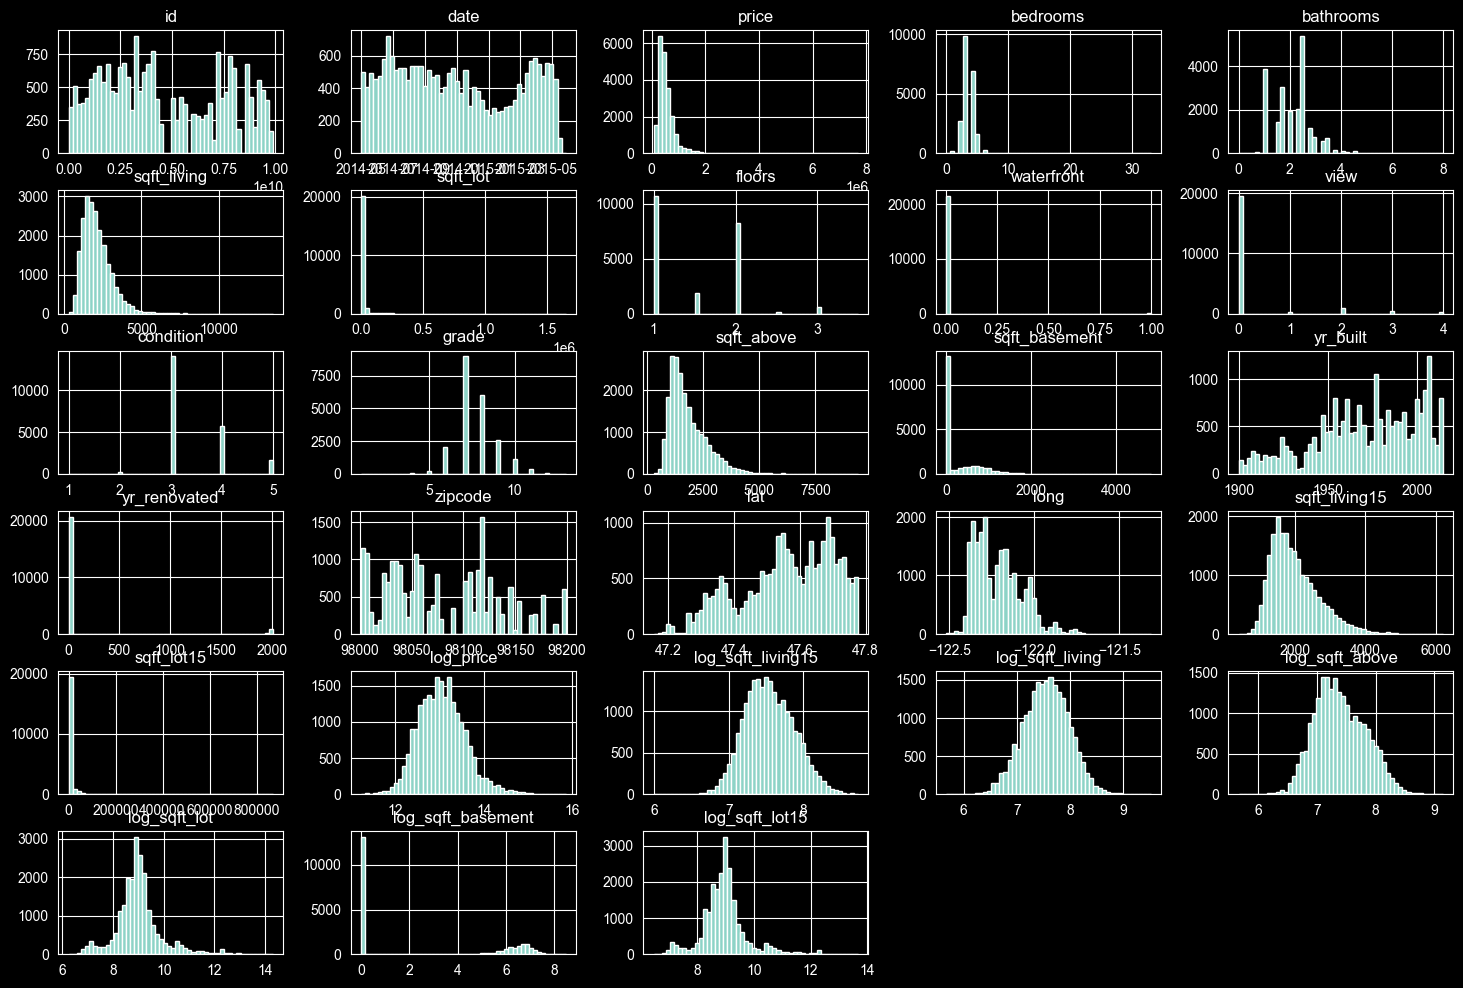

In [66]:
data.hist(figsize=(18,12), bins=50)

Data after transformation feels more stable to read, left only _log_sqft_basement_ because most of the house exist don't have basement. We can fix it by adding one more columns to distinguish between the one with basement and the one without basement

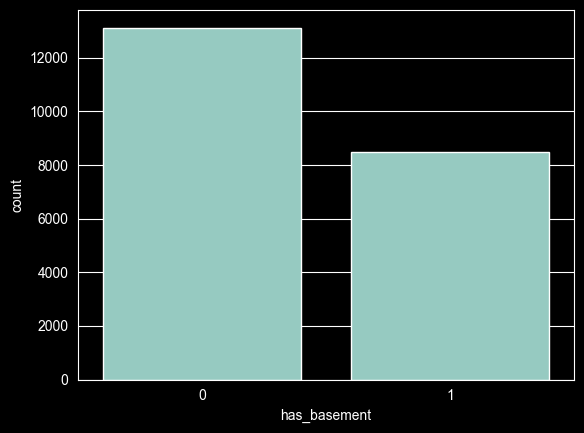

In [67]:
data['has_basement'] = (data['sqft_basement'] > 0).astype(int)
sns.countplot(x=data['has_basement'])
plt.show()

Since we already transformed the data using log transform, we may dump the original data to prevent any multicollinear using the previous _cols to log_ to loop drop

In [68]:
data = data.drop(columns=[col for col in col_to_log if col in data.columns])
data.head()

,id,date,price,bedrooms,bathrooms,floors,waterfront,view,condition,grade,...,lat,long,log_price,log_sqft_living15,log_sqft_living,log_sqft_above,log_sqft_lot,log_sqft_basement,log_sqft_lot15,has_basement
0,7129300520,2014-10-13,221900.0,3,1.00,1.0,0,0,3,7,...,47.5112,-122.257,12.309982,7.201171,7.074117,7.074117,8.639588,0.000000,8.639588,0
1,6414100192,2014-12-09,538000.0,3,2.25,2.0,0,0,3,7,...,47.7210,-122.319,13.195614,7.433075,7.852050,7.682943,8.887791,5.993961,8.941153,1
2,5631500400,2015-02-25,180000.0,2,1.00,1.0,0,0,3,6,...,47.7379,-122.233,12.100712,7.908755,6.647688,6.647688,9.210440,0.000000,8.995041,0
3,2487200875,2014-12-09,604000.0,4,3.00,1.0,0,0,5,7,...,47.5208,-122.393,13.311329,7.215975,7.581210,6.957497,8.517393,6.814543,8.517393,1
4,1954400510,2015-02-18,510000.0,3,2.00,1.0,0,0,3,8,...,47.6168,-122.045,13.142166,7.496097,7.427144,7.427144,8.997271,0.000000,8.923191,0


To address skewness in numerical features, several variables (e.g., living area, lot size, basement area) were transformed using a logarithmic scale. This improves distribution symmetry and stabilizes variance, which is beneficial for linear modeling.

Since the log-transformed features capture the same underlying information as their original counterparts, retaining both would introduce multicollinearity. To prevent redundancy and ensure model stability, the original (non-transformed) features were removed.

As a result, each physical attribute is now represented by a single, more statistically suitable feature.

Our next move is to find the relationship between features and target linear for linear model

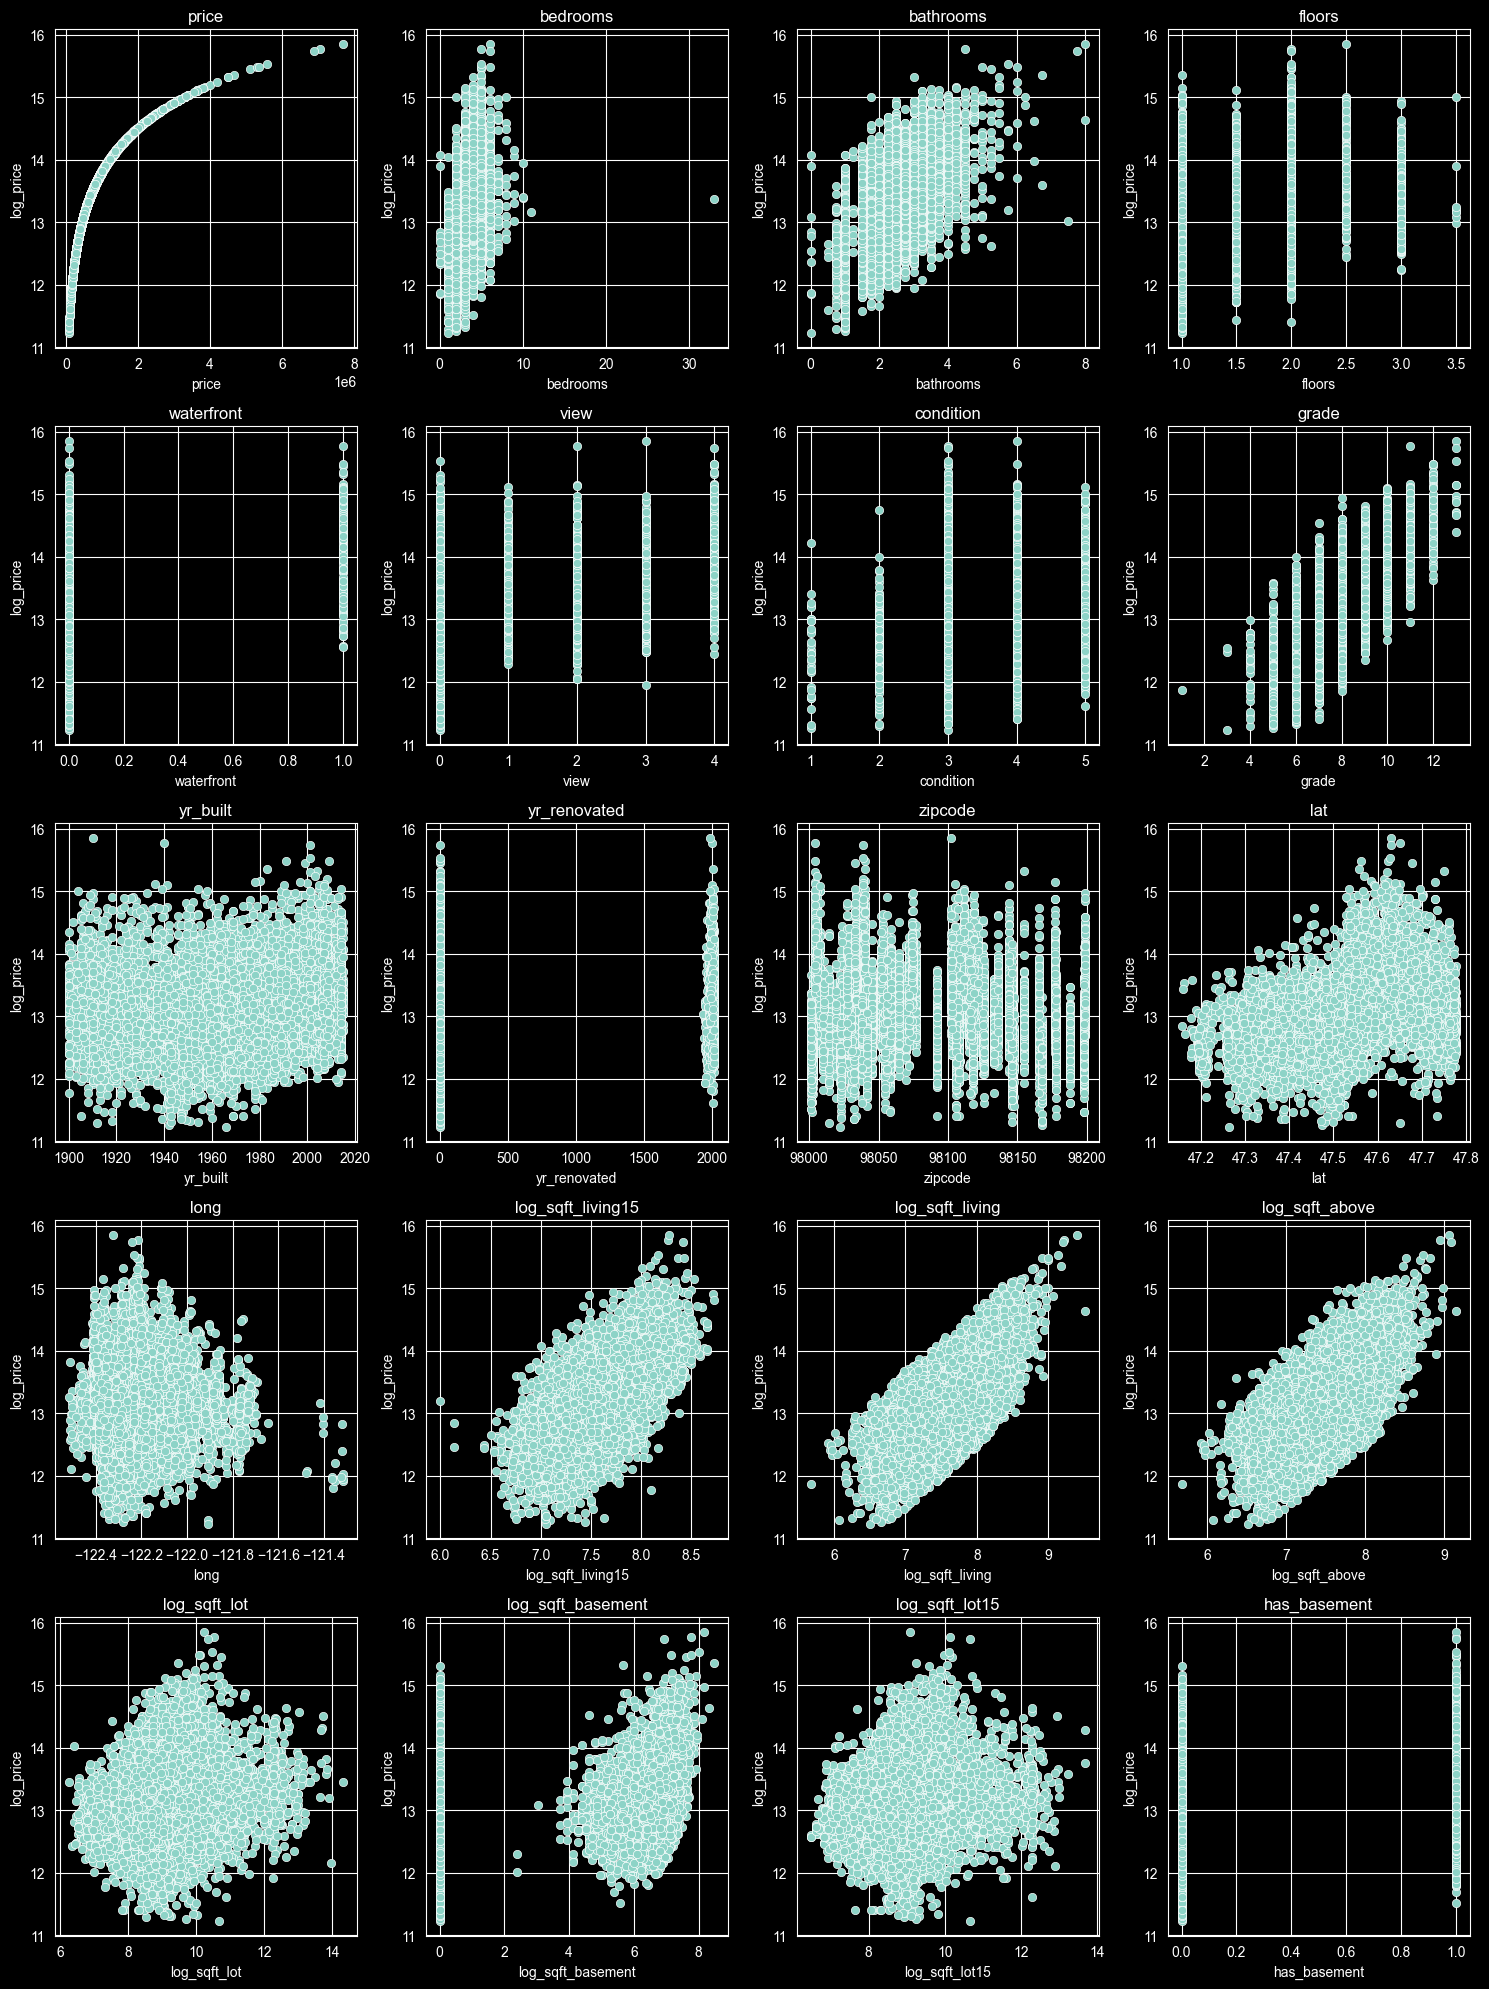

In [69]:
cols = [col for col in data.columns if col not in ['log_price', 'id', 'date']]

n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(x=data[col], y=data['log_price'])
    plt.title(col)

plt.tight_layout()
plt.show()

Scatter plot analysis shows that features related to property size (e.g., log_sqft_living, log_sqft_above, log_sqft_living15) exhibit strong positive linear relationships with the target variable (log_price). This confirms that the earlier log transformation successfully improved linearity.

Categorical-like numerical features (e.g., grade, bathrooms) also show meaningful trends, though in a stepwise manner.

Several features (e.g., bedrooms, floors, zipcode, long) display weak or noisy relationships with the target and may contribute less to model performance.

Additionally, the raw price variable is excluded to prevent data leakage, as it directly overlaps with the target.

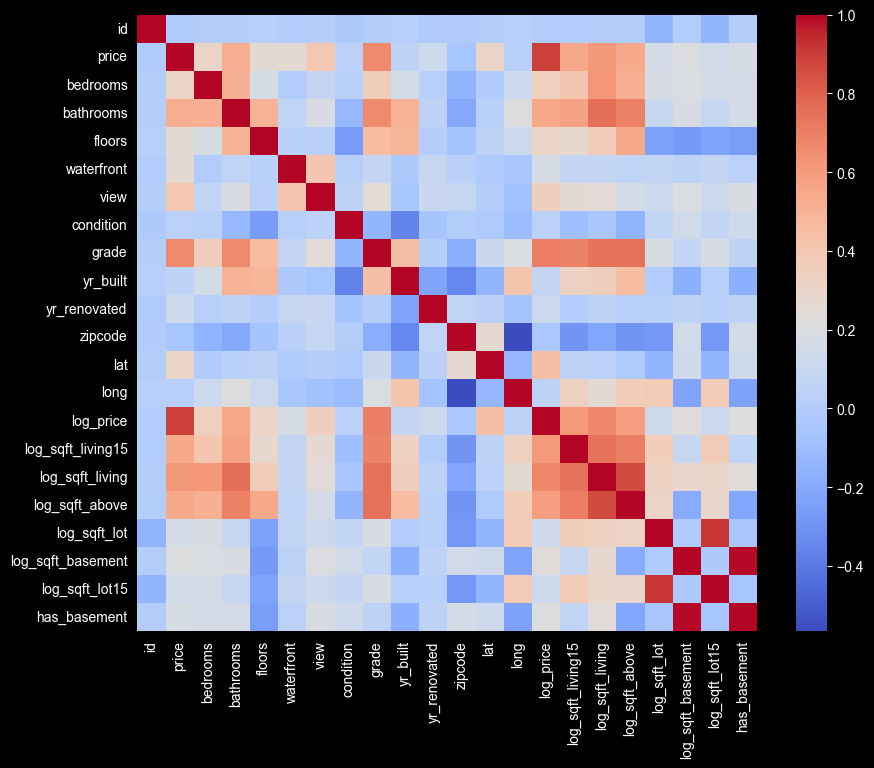

In [70]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')
plt.show()

## Oullier Handling



In [75]:
data = data[data['bedrooms'] < 15]

In [76]:
lower = data['log_price'].quantile(0.01)
upper = data['log_price'].quantile(0.99)

data = data[(data['log_price'] >= lower) & (data['log_price'] <= upper)]

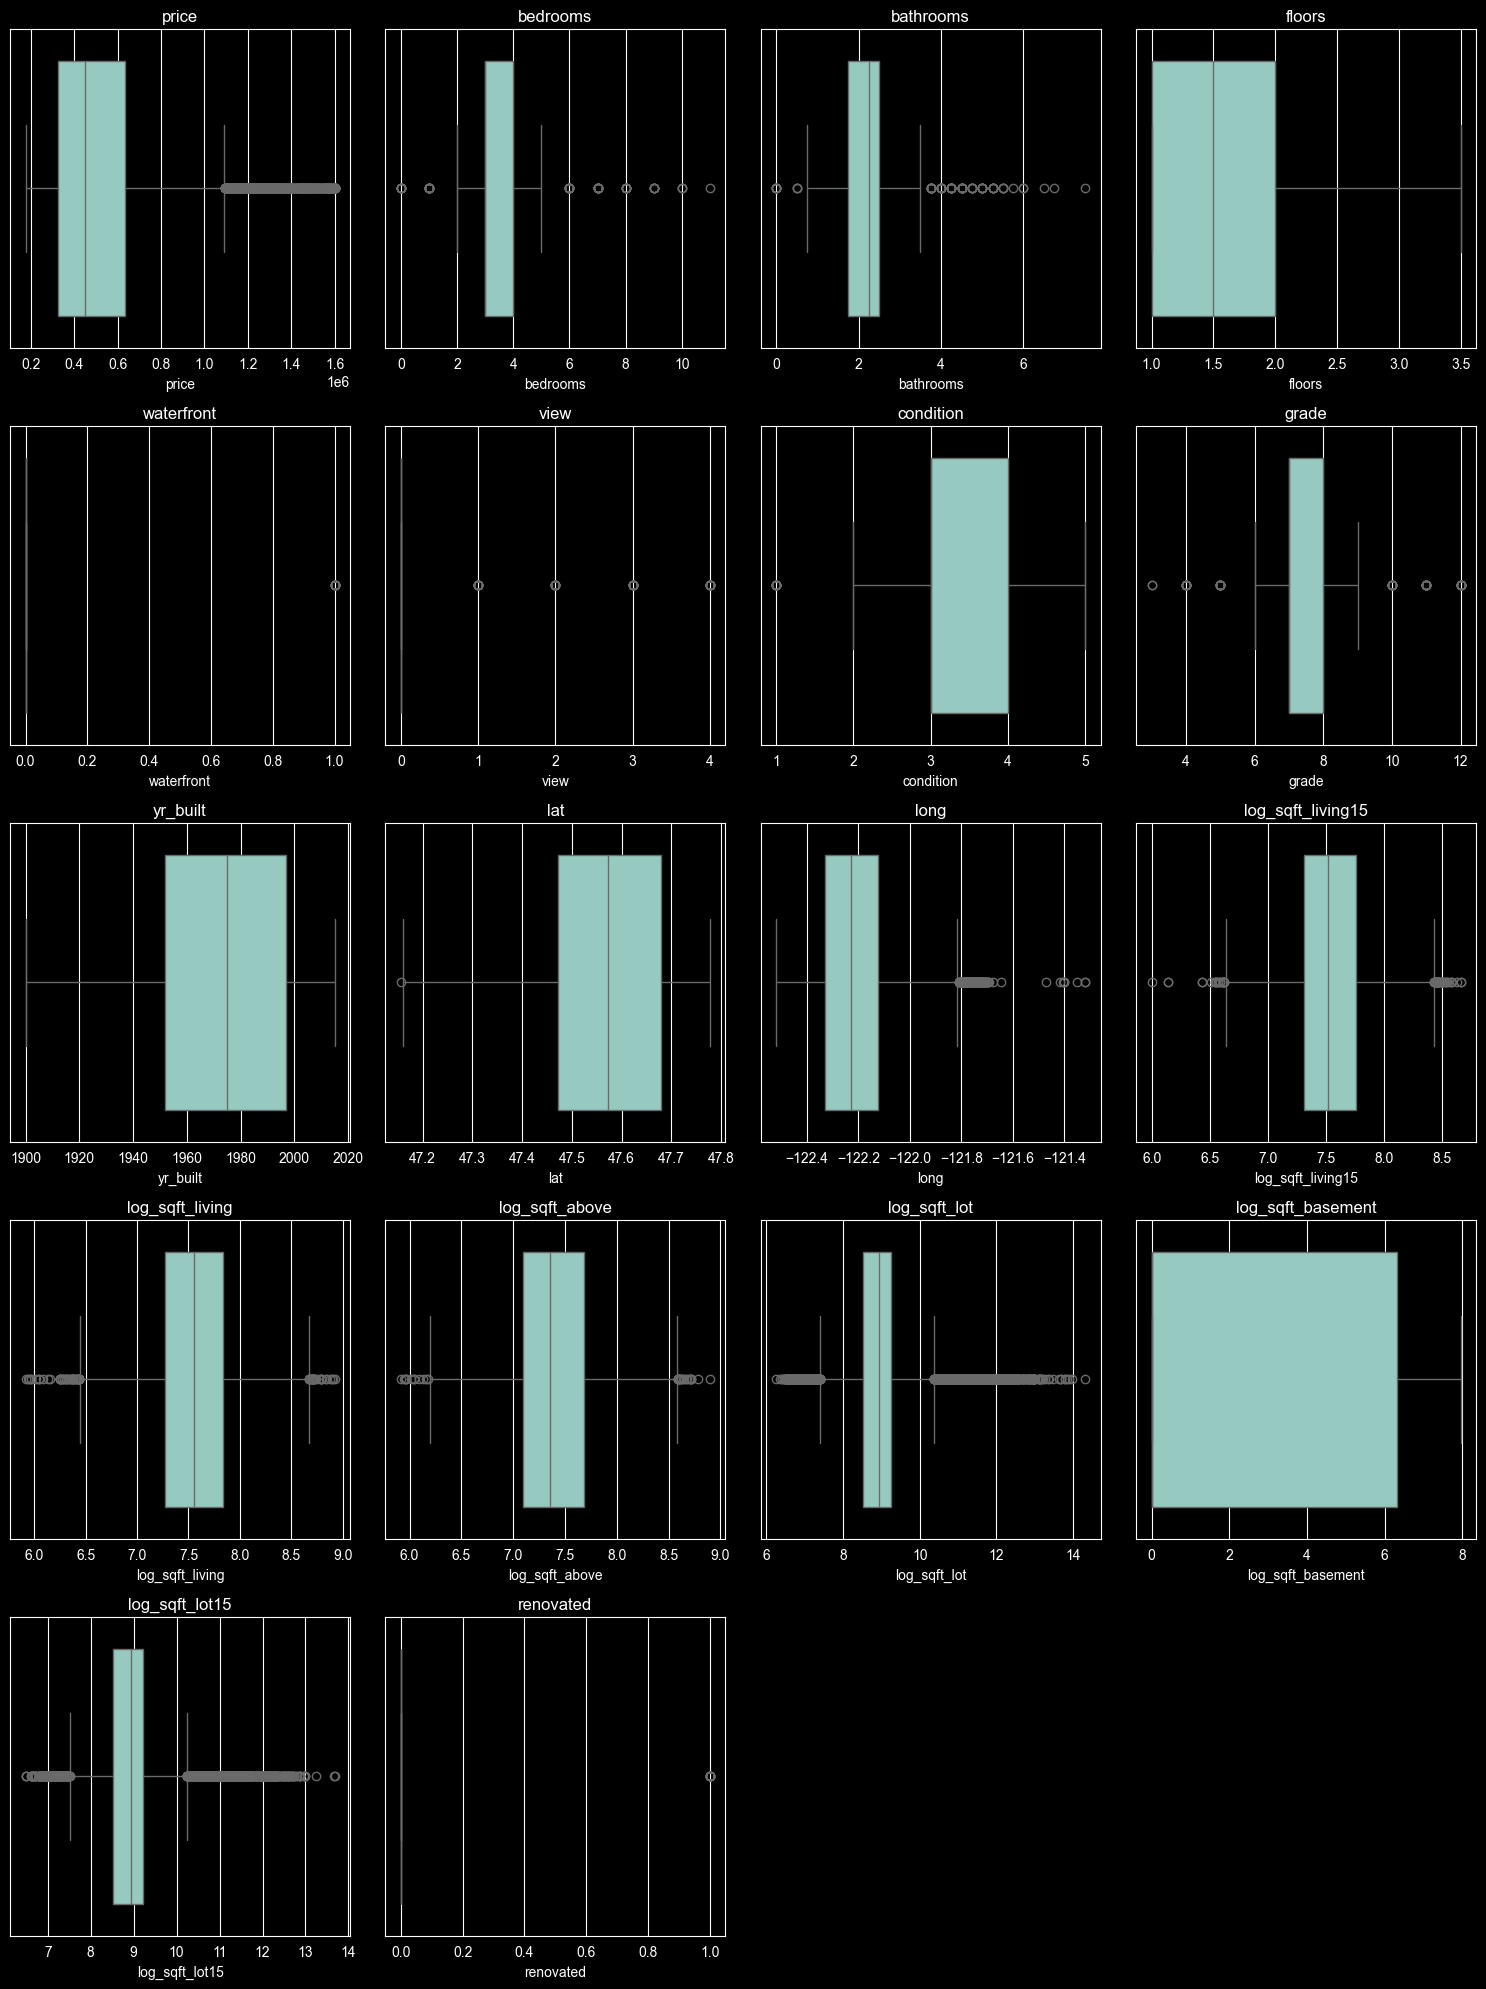

In [79]:
cols = [
    col for col in data.columns
    if col not in ['log_price', 'id', 'date', 'zipcode', 'has_basement']
]

n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Boxplot analysis initially suggests the presence of numerous outliers across several features. However, this is largely due to the nature of the data rather than actual anomalies.

Many numerical features, particularly those related to property size (e.g., log_sqft_lot, log_sqft_living), exhibit wide natural variation. As a result, the boxplot method (based on the 1.5×IQR rule) flags a significant number of observations as outliers, even though they represent valid data points.

Additionally, several features (e.g., waterfront, view, condition, grade) are discrete or categorical in nature, which causes boxplots to display artificial outlier patterns that do not reflect true anomalies.

A genuine outlier issue was identified in the bedrooms feature, where unusually high values (e.g., >15) are unrealistic and were removed.

Overall, no aggressive outlier removal was applied, as most detected “outliers” reflect legitimate variation within the housing market rather than data errors.

This mark the ends of EDA, our next step is about _Feature Engineering_ ,_Modelling_, and so on. The most important thing is to make a preprocess function in our separated folder 'src/preprocess.py', a function that takes raw data → returns cleaned, model-ready data